<a href="https://colab.research.google.com/github/PriyankaDevaprasad/Diamond_Price_Prediction/blob/main/notebook/Diamond_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **💎 Diamond Price Prediction**

#**Project Introduction**

This project develops an end-to-end machine learning solution for two complementary tasks: diamond price prediction and market segmentation. Multiple machine learning regression algorithms and an Artificial Neural Network (ANN) are evaluated to predict diamond prices. In addition, K-Means clustering is used to identify meaningful groups of diamonds based on their characteristics, with PCA used to visualize the resulting clusters.

##**Problem Statement**

The diamond market heavily depends on multiple quality attributes like carat, cut, clarity, and color to decide pricing. Accurately predicting diamond prices helps in pricing strategy and customer targeting. Additionally, segmenting diamonds into meaningful market groups can assist sellers in inventory management and buyers in finding suitable products.


### **Objective**

The objective of this project is to develop a machine learning model
that predicts the price of a diamond based on its physical and
quality-related characteristics.

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**Loading Dataset**

In [2]:
diamond=pd.read_csv("/content/diamonds.csv")

**Understanding Dataset**

In [3]:
print(diamond.shape)


(53940, 10)


In [4]:
print(diamond.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
None


In [5]:
diamond.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [6]:
#Count of Unique Values in Each Column
diamond.nunique()

,0
carat,273
cut,5
color,7
clarity,8
depth,184
table,127
price,11602
x,554
y,552
z,375


In [7]:
diamond.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Null Values**

In [8]:
diamond.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


**Removal of zero values in x,y,z**


In [9]:
zero_x=diamond[diamond['x']==0]
zero_y=diamond[diamond['y']==0]
zero_z=diamond[diamond['z']==0]
print("No. of zeros in x : ", len(zero_x))
print("No. of zeros in y : ", len(zero_y))
print("No. of zeros in z : ", len(zero_z))

No. of zeros in x :  8
No. of zeros in y :  7
No. of zeros in z :  20


In [10]:
# Remove invalid zeros for dimension variables
data=['cut','color','clarity']
for col in ['x', 'y', 'z']:
    # Replace 0 values with NaN
    diamond[col] = diamond[col].replace(0, np.nan)
    diamond[col] = diamond[col].fillna(diamond.groupby(data)[col].transform('mean'))


In [11]:
diamond.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Outlier Detection**

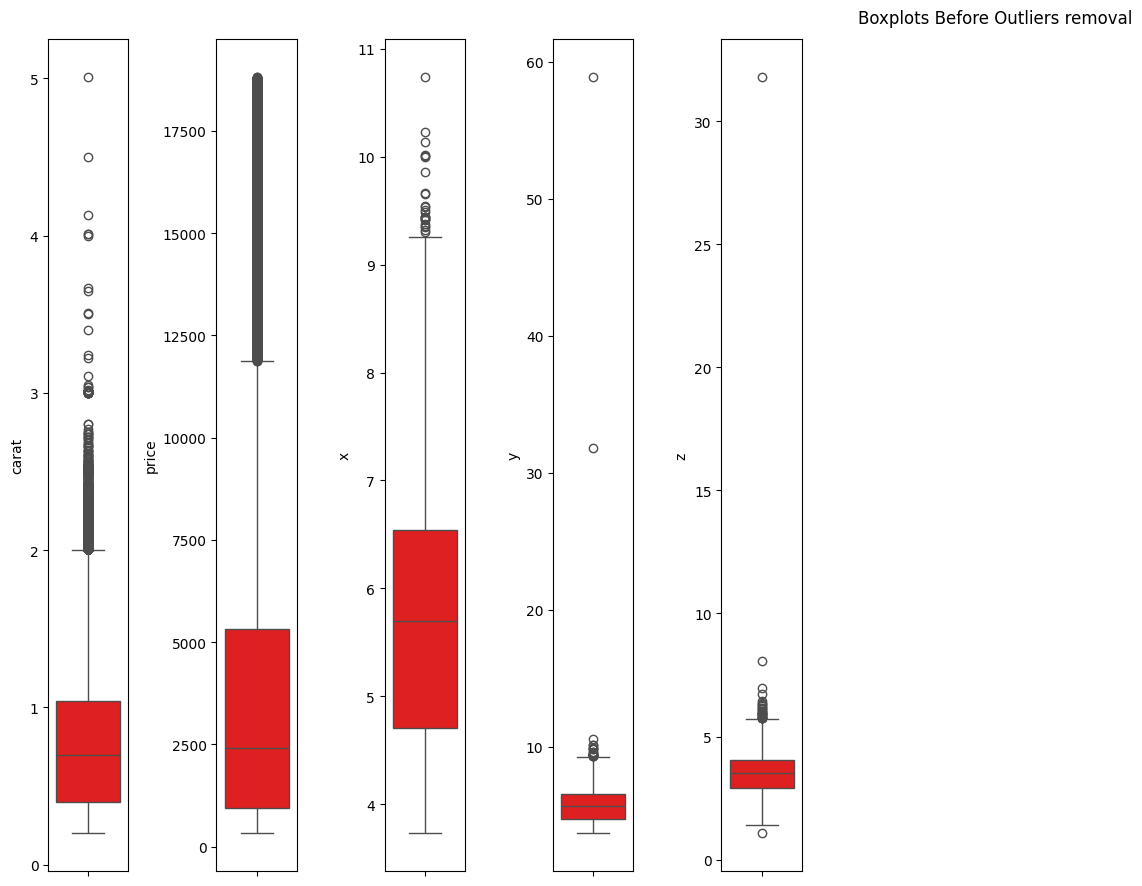

In [12]:
# Visual check for outliers
num_cols = ['carat', 'price', 'x', 'y', 'z']
plt.figure(figsize=(20, 9))
plt.suptitle("Boxplots Before Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=diamond[num_cols[i]],color='red')
    plt.tight_layout()

**Handling Outlier**

In [13]:
diamond[diamond['y']>15]

,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.9,8.06
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.8,5.12


In [14]:
diamond=diamond[diamond['y']<15].copy()

In [15]:
diamond[diamond['z']>30]

,carat,cut,color,clarity,depth,table,price,x,y,z
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.8


In [16]:
diamond=diamond[diamond['z']<30].copy()

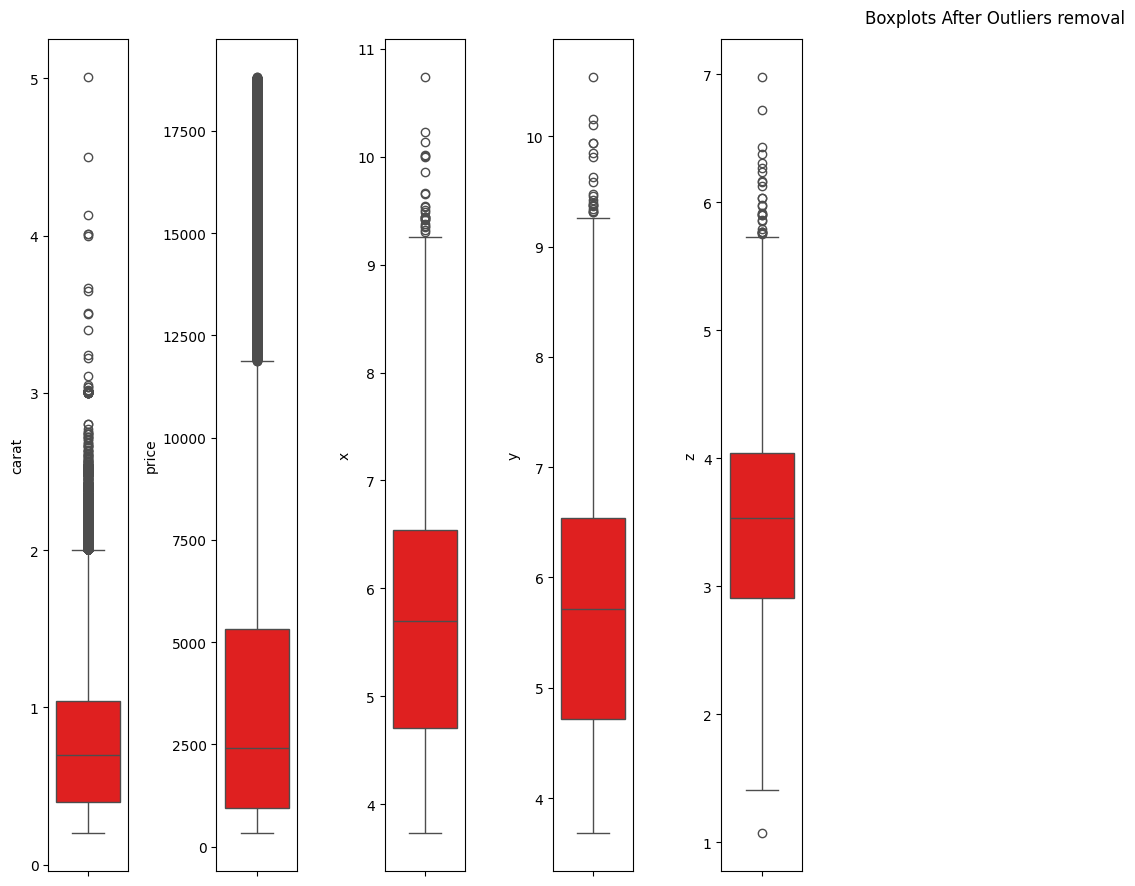

In [17]:
# Visual check for outliers after removal
numcols = ['carat', 'price', 'x', 'y', 'z']
plt.figure(figsize=(20, 9))
plt.suptitle("Boxplots After Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=diamond[num_cols[i]],color='red')
    plt.tight_layout()

**Skewness Detection**

In [18]:
diamond[['carat','price','x','y','z']].skew()

,0
carat,1.116617
price,1.618465
x,0.398329
y,0.392736
z,0.393361


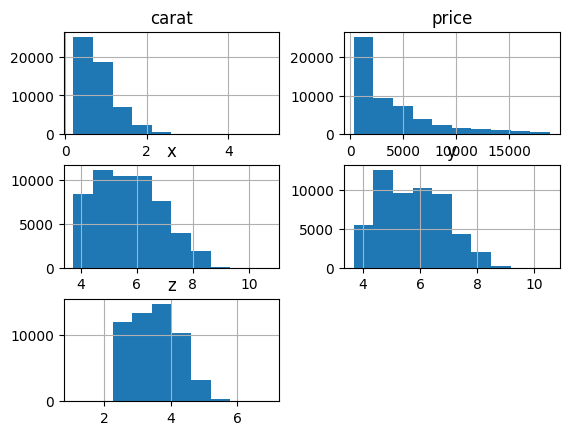

In [19]:
diamond[['carat','price','x','y','z']].hist()
plt.show()

In [20]:
print("\n🔧 Applying Log Transformation for Skewness...")
for col in ['carat', 'price']:
    diamond[col] = np.log1p(diamond[col])
diamond[['carat','price']].skew()


🔧 Applying Log Transformation for Skewness...


,0
carat,0.580592
price,0.115926


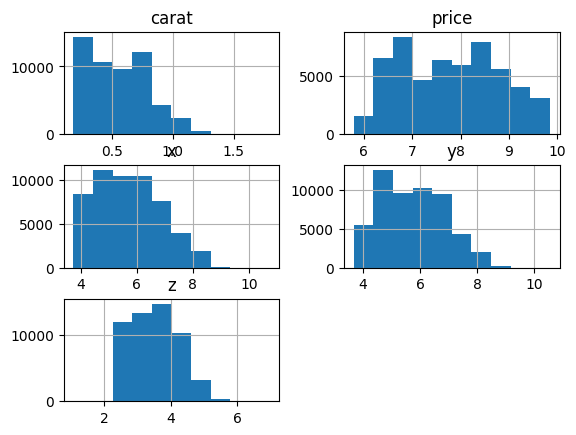

In [21]:
diamond[['carat','price','x','y','z']].hist()
plt.show()

# **EDA**

/tmp/ipykernel_1151/530413303.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diamond, x=var, ax=ax, palette='viridis')
/tmp/ipykernel_1151/530413303.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diamond, x=var, ax=ax, palette='viridis')
/tmp/ipykernel_1151/530413303.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diamond, x=var, ax=ax, palette='viridis')


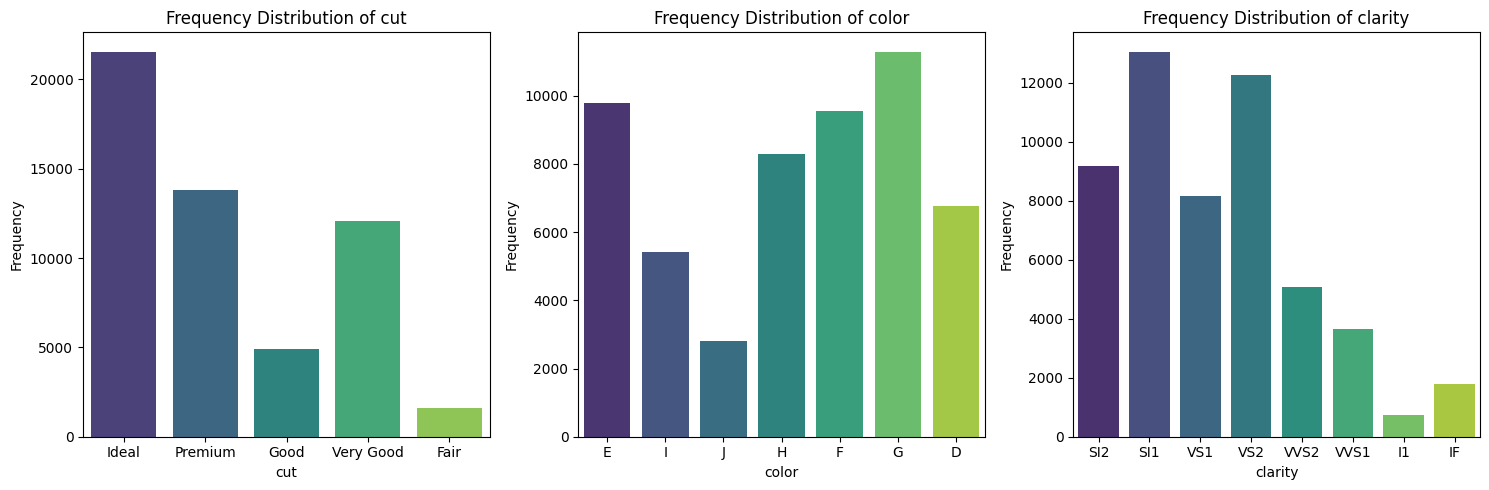

In [22]:
# bar plots for the categorical variables cut, color, and clarity
# Define the categorical variables
categorical_vars = ['cut', 'color', 'clarity']

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_vars), figsize=(15, 5))

# Plot bar plots for each categorical variable
for ax, var in zip(axes, categorical_vars):
    sns.countplot(data=diamond, x=var, ax=ax, palette='viridis')
    ax.set_title(f'Frequency Distribution of {var}')
    ax.set_xlabel(f'{var}')
    ax.set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

**Distribution Plot**

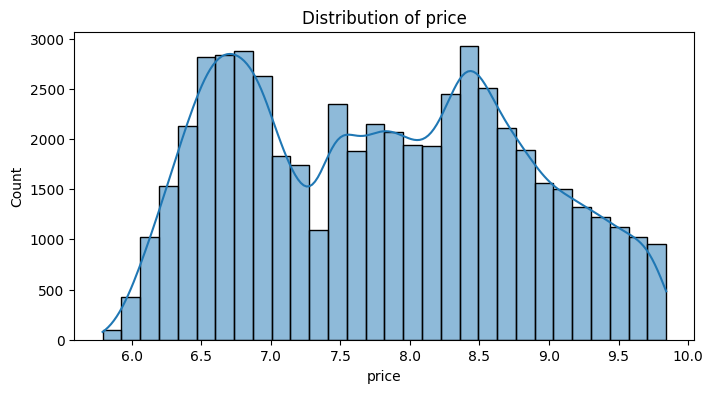

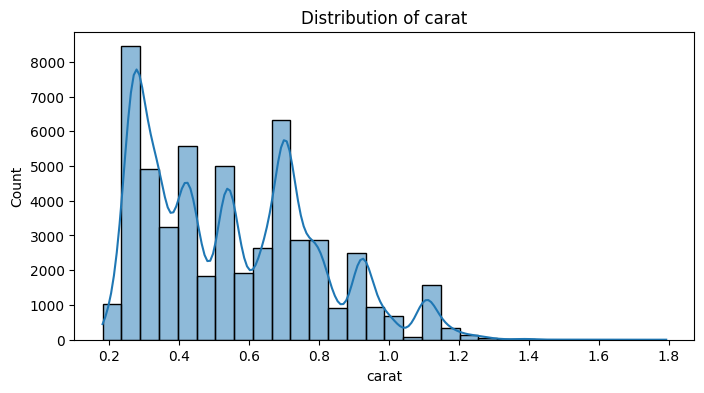

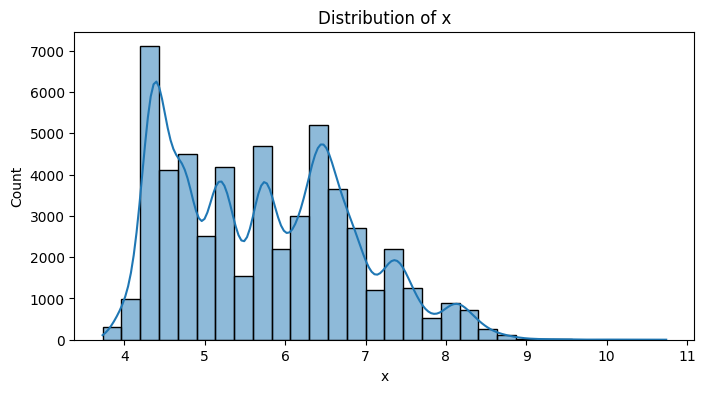

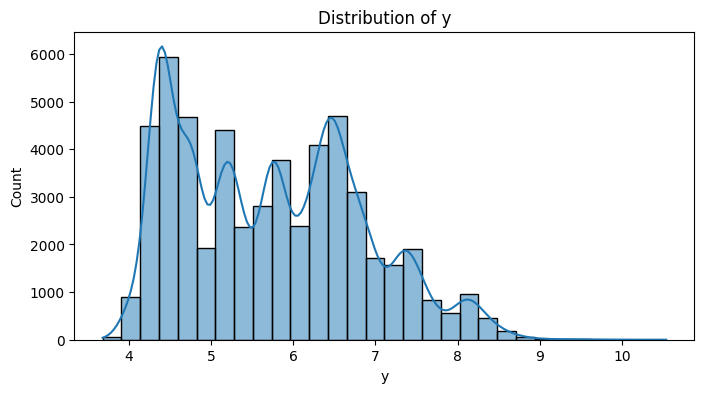

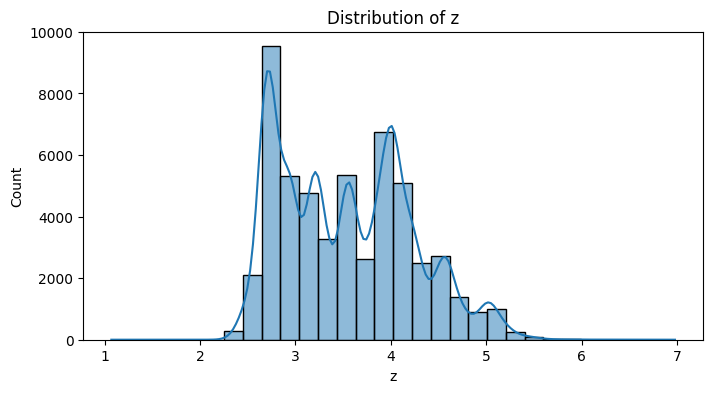

In [23]:
# 1. Distribution plots for price, carat, x, y, z
numcols = ['price', 'carat', 'x', 'y', 'z']
for col in numcols:
    plt.figure(figsize=(8, 4))
    sns.histplot(diamond[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

**Count Plot**

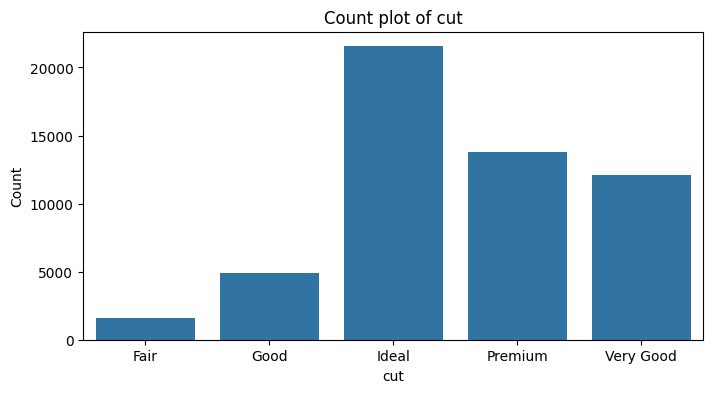

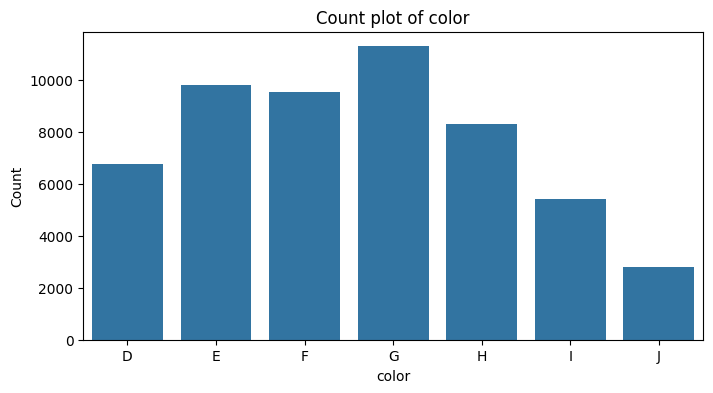

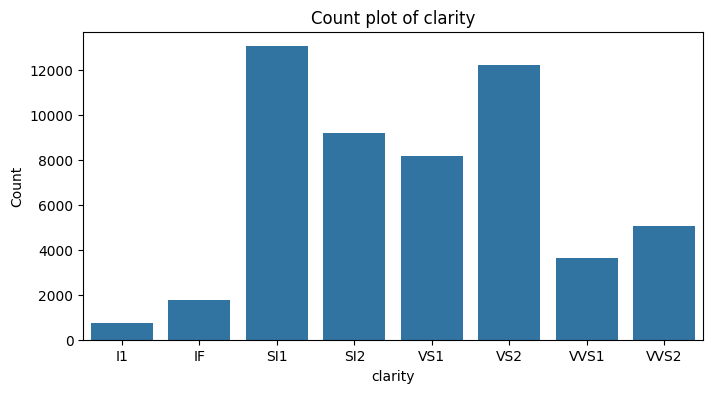

In [24]:
# 2. Count plots for categorical features (cut, color, clarity)
catcols = ['cut', 'color', 'clarity']
for col in catcols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=diamond, order=sorted(diamond[col].unique()))
    plt.title(f'Count plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

**Box Plot**

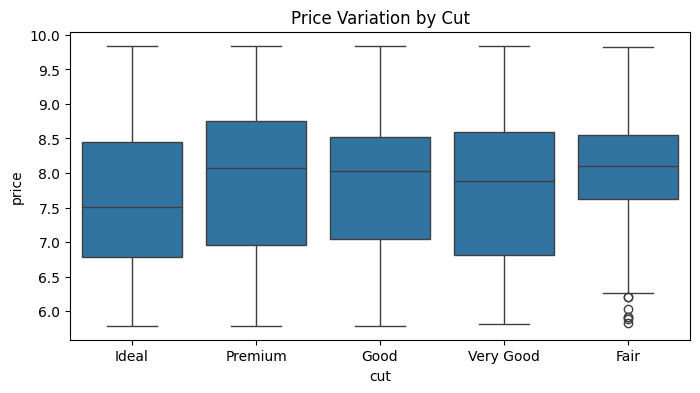

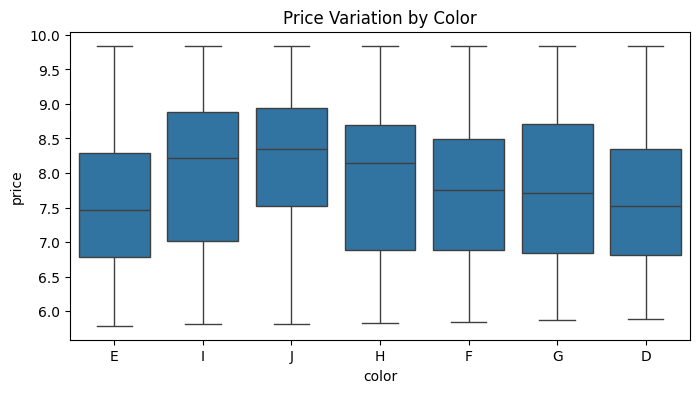

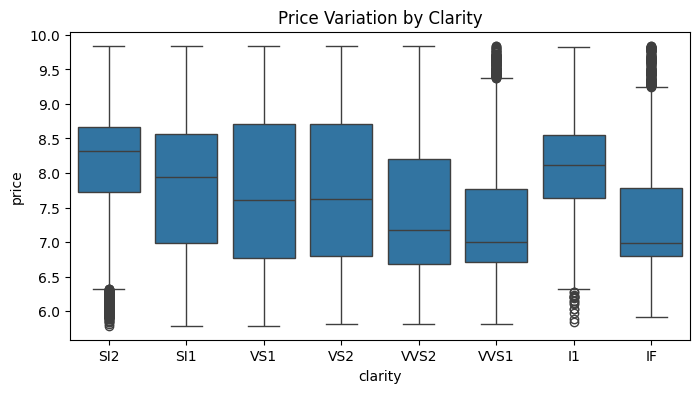

In [25]:
# 3. Price variation with carat, cut, color, clarity using boxplots
plt.figure(figsize=(8, 4))
sns.boxplot(x='cut', y='price', data=diamond)
plt.title('Price Variation by Cut')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='color', y='price', data=diamond)
plt.title('Price Variation by Color')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='clarity', y='price', data=diamond)
plt.title('Price Variation by Clarity')
plt.show()

**Heatmap**

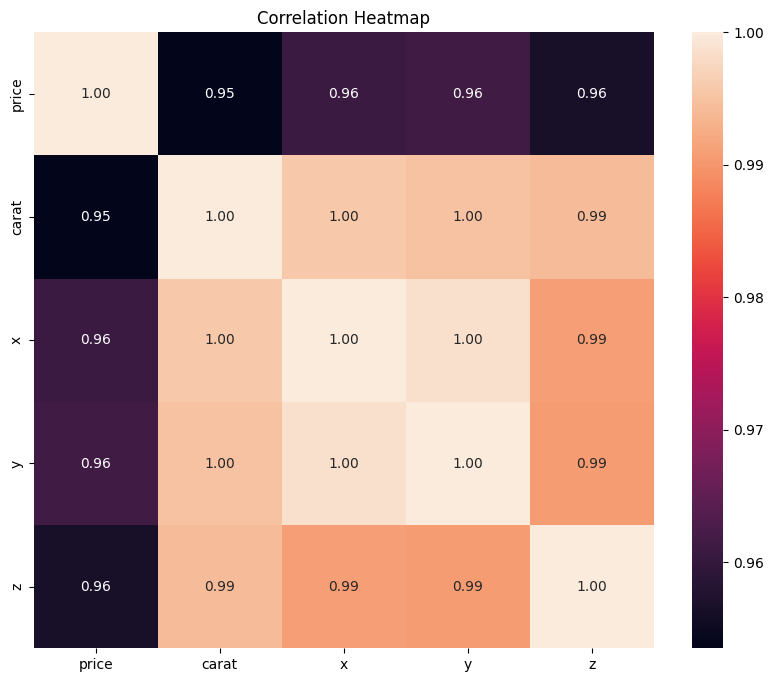

In [26]:
# 4. Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(diamond[numcols].corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Pairplot**

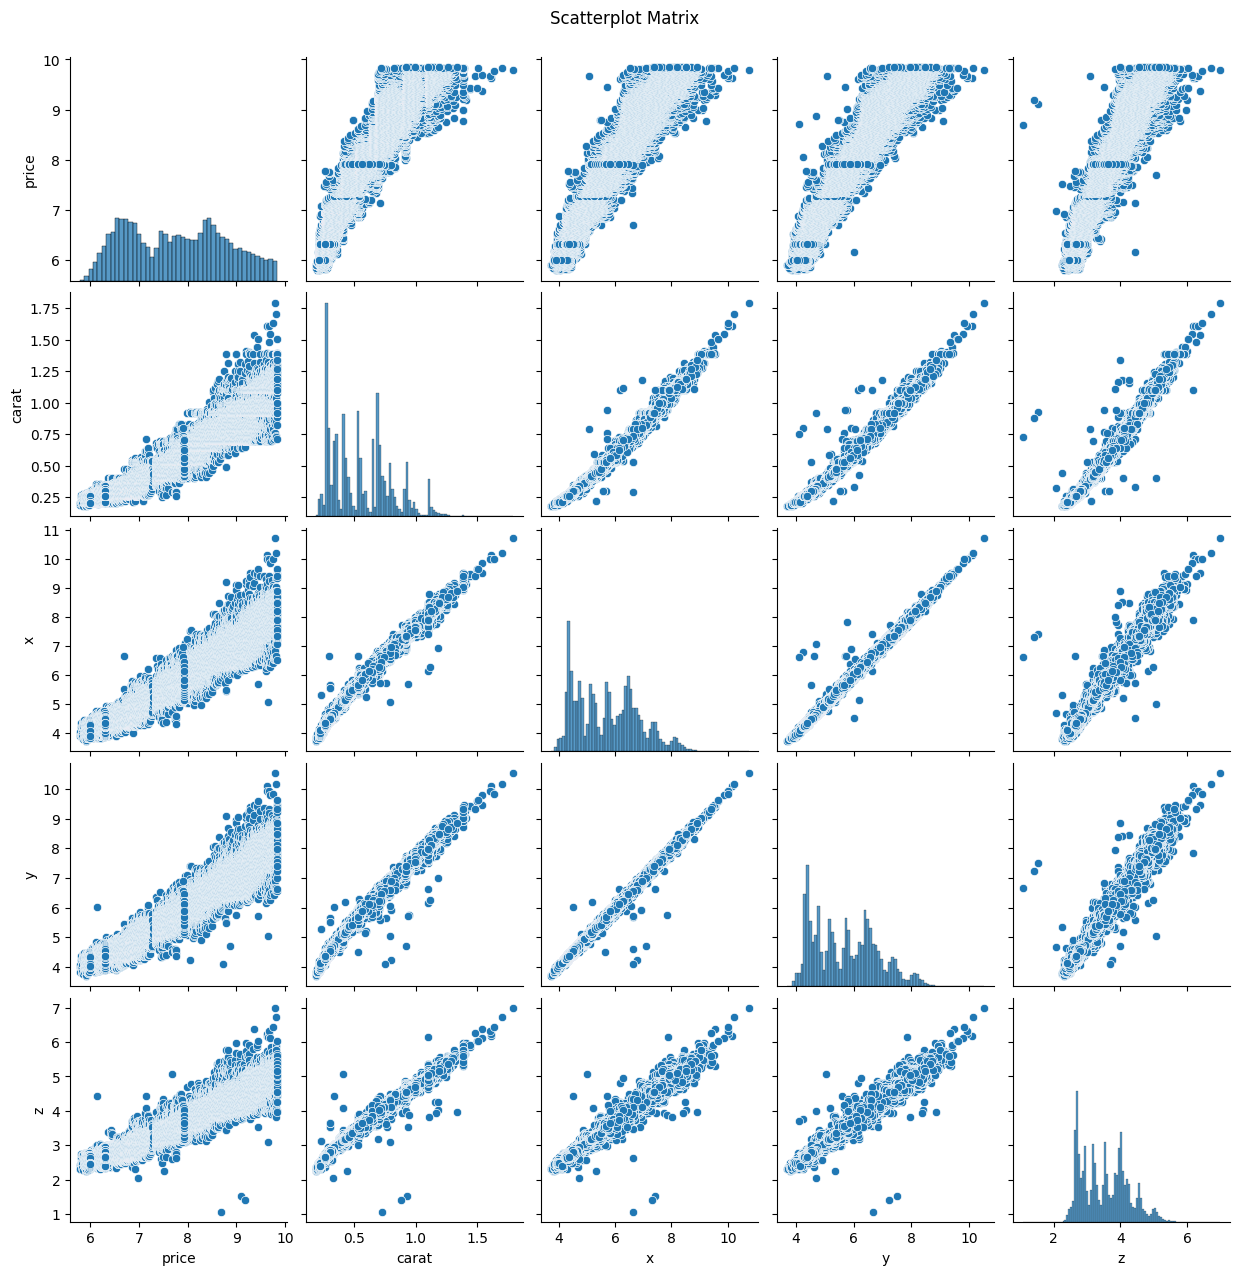

In [27]:
# 5. Scatterplot matrix for carat, x, y, z, and price
sns.pairplot(diamond[numcols])
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

**Regression Plot**

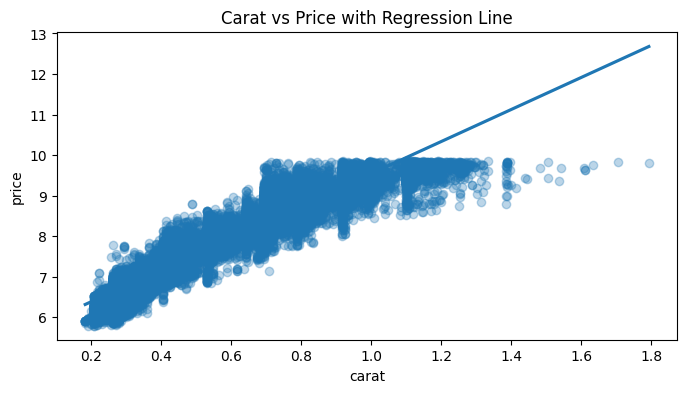

In [28]:
# 7. Carat vs. Price regression lineplot
plt.figure(figsize=(8, 4))
sns.regplot(x='carat', y='price', data=diamond, scatter_kws={'alpha':0.3})
plt.title('Carat vs Price with Regression Line')
plt.show()

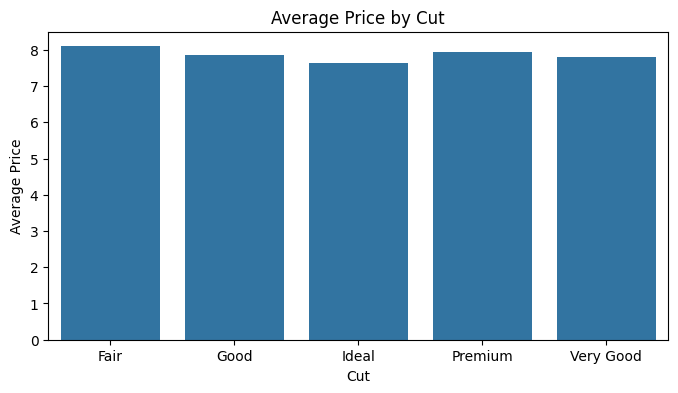

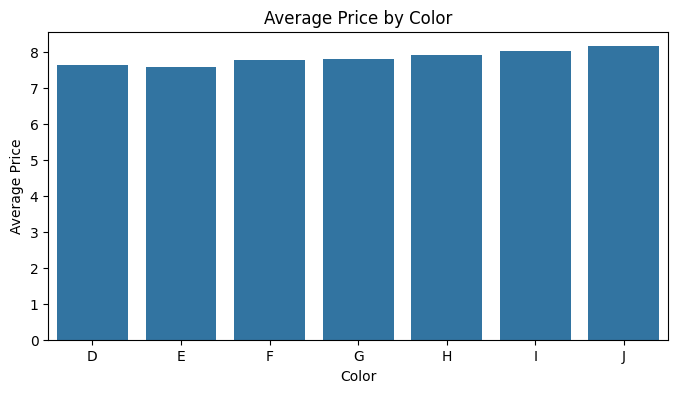

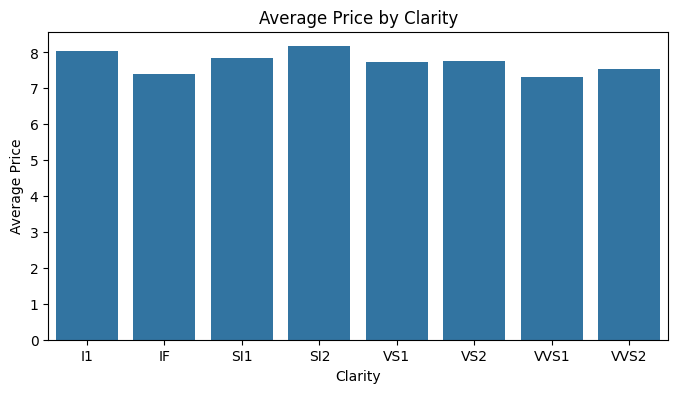

In [29]:
# 8. Average price per cut, color, clarity categories using bar plots
avg_price_cut = diamond.groupby('cut')['price'].mean().sort_index()
avg_price_color = diamond.groupby('color')['price'].mean().sort_index()
avg_price_clarity = diamond.groupby('clarity')['price'].mean().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_price_cut.index, y=avg_price_cut.values)
plt.title('Average Price by Cut')
plt.xlabel('Cut')
plt.ylabel('Average Price')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_price_color.index, y=avg_price_color.values)
plt.title('Average Price by Color')
plt.xlabel('Color')
plt.ylabel('Average Price')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_price_clarity.index, y=avg_price_clarity.values)
plt.title('Average Price by Clarity')
plt.xlabel('Clarity')
plt.ylabel('Average Price')
plt.show()

**FEATURE ENGINEERING**

Volume

In [30]:
diamond['volume'] = diamond['x'] * diamond['y'] * diamond['z']

Price Per carat

In [31]:
diamond['PricePerCarat'] = diamond['price'] / diamond['carat']

In [32]:
mean_price_per_carat = diamond['PricePerCarat'].mean()
print(f"Mean PricePerCarat saved: {mean_price_per_carat:.4f}")

Mean PricePerCarat saved: 16.2068


Dimension ratio

In [33]:
diamond['dimension_ratio'] = (diamond['x'] + diamond['y']) / (2 * diamond['z'])

Carat Category: Light (<0.5), Medium (0.5-1.5), Heavy (>1.5)

In [34]:
# Reverse log-transform to get original carat values
diamond['carat_original'] = np.expm1(diamond['carat'])

def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif 0.5 <= c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

diamond['carat_category'] = diamond['carat_original'].apply(carat_category)

In [35]:
# Convert price to INR
usd_to_inr = 94.1
diamond['price_inr'] = diamond['price'] * usd_to_inr

In [36]:
diamond.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z,volume,PricePerCarat,dimension_ratio,carat_original,carat_category,price_inr
0,0.207014,Ideal,E,SI2,61.5,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,1.631687,0.23,Light,544.835252
1,0.190620,Premium,E,SI1,59.8,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,1.673160,0.21,Light,544.835252
2,0.207014,Good,E,VS1,56.9,65.0,5.793014,4.05,4.07,2.31,38.076885,27.983657,1.757576,0.23,Light,545.122581
3,0.254642,Premium,I,VS2,62.4,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,1.602662,0.29,Light,547.109683
4,0.270027,Good,J,SI2,63.3,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,1.580000,0.31,Light,547.390160


**ENCODING**

In [37]:
# ORDINAL ENCODING
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J','I','H','G','F','E','D'][::-1]  # Ensures D is highest
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

ordinal = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

diamond[['cut','color','clarity']] = ordinal.fit_transform(diamond[['cut','color','clarity']])

In [38]:
with open('ordinal_encoder.pkl', 'wb') as file:
    pickle.dump(ordinal, file)

In [39]:
diamond.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume,PricePerCarat,dimension_ratio,carat_original,carat_category,price_inr
0,0.207014,4.0,1.0,1.0,61.5,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,1.631687,0.23,Light,544.835252
1,0.190620,3.0,1.0,2.0,59.8,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,1.673160,0.21,Light,544.835252
2,0.207014,1.0,1.0,4.0,56.9,65.0,5.793014,4.05,4.07,2.31,38.076885,27.983657,1.757576,0.23,Light,545.122581
3,0.254642,3.0,5.0,3.0,62.4,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,1.602662,0.29,Light,547.109683
4,0.270027,1.0,6.0,1.0,63.3,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,1.580000,0.31,Light,547.390160


# **FEATURE SELECTION**

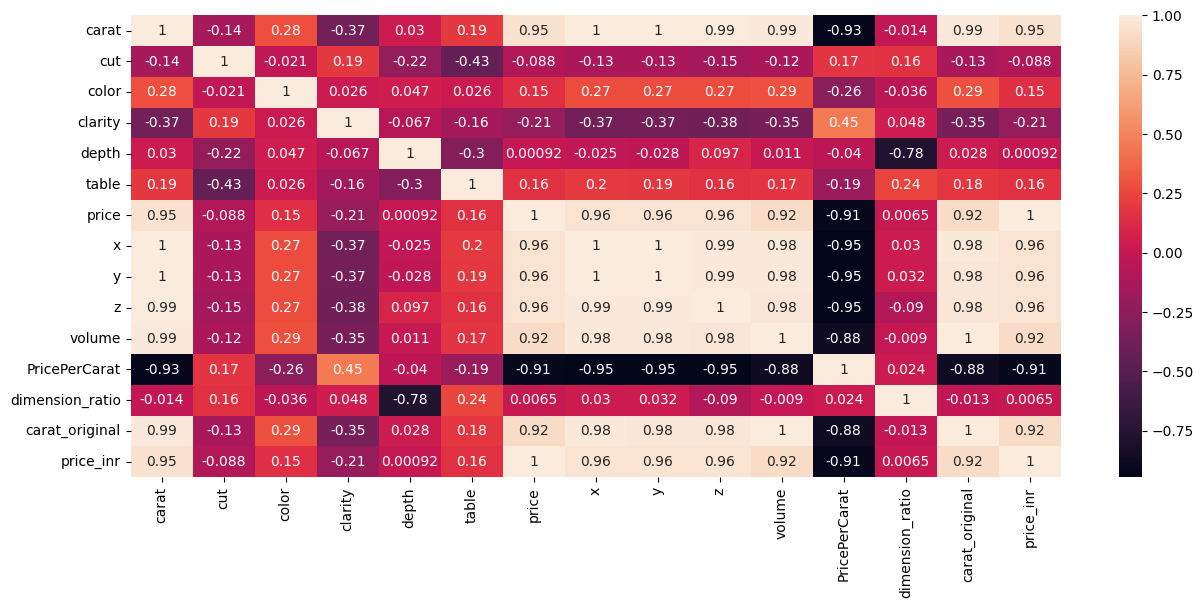

In [40]:
# Correlation Matrix
numeric_cols_for_corr = diamond.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = diamond[numeric_cols_for_corr].corr()
plt.figure(figsize=(15, 6))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [41]:
# Random Forest Feature Importance
feature_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']
X_temp = diamond[feature_cols]
y_temp = diamond['price']

rf = RandomForestRegressor(random_state=1, n_estimators=50)
rf.fit(X_temp, y_temp)
importances = pd.Series(rf.feature_importances_, index=X_temp.columns)
print("\nTop 6 Important Features:")
print(importances.sort_values(ascending=False).head(6))


Top 6 Important Features:
y          0.856668
carat      0.072476
clarity    0.030202
x          0.019004
color      0.016098
z          0.001918
dtype: float64


In [42]:
# RFE - Select top 5 features
rfe = RFE(rf, n_features_to_select=5)
rfe.fit(X_temp, y_temp)
selected_features = list(X_temp.columns[rfe.support_])
print(f"\nRFE Selected Features: {selected_features}")


RFE Selected Features: ['carat', 'x', 'y', 'color', 'clarity']


In [43]:
# Use selected features for regression
features_final = selected_features  # Example: ['carat', 'x', 'y', 'color', 'clarity']

In [44]:
features_final

['carat', 'x', 'y', 'color', 'clarity']

# **MODEL BUILDING**

Splitting the data

In [45]:
X_final = diamond[features_final]
y = diamond['price']

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [46]:
# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

results = {}
predictions = {}

print("\n📊 Model Performance:")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f"{name:20s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")


📊 Model Performance:
Linear Regression    | MAE: 0.1436 | RMSE: 0.1867 | R2: 0.9656
Decision Tree        | MAE: 0.0873 | RMSE: 0.1281 | R2: 0.9838
Random Forest        | MAE: 0.0680 | RMSE: 0.0979 | R2: 0.9906
KNN                  | MAE: 0.0733 | RMSE: 0.1050 | R2: 0.9891
XGBoost              | MAE: 0.0658 | RMSE: 0.0922 | R2: 0.9916


# **ANN**

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

# --------------------------------------------------
# 1. Convert data to PyTorch tensors
# --------------------------------------------------

X_train_tensor = torch.tensor(X_train.values,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1, 1)

class ANN(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

# 3. Create model

input_dim = X_train.shape[1]
ann = ANN(input_dim)
print(ann)

# 4. Loss function and optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(ann.parameters(),lr=0.001)

# 5. Train the model
epochs = 30
batch_size = 32

for epoch in range(epochs):

    ann.train()
    # Shuffle training data
    indices = torch.randperm(len(X_train_tensor))
    total_loss = 0
    for start in range(0, len(X_train_tensor), batch_size):

        batch_indices = indices[start:start + batch_size]
        X_batch = X_train_tensor[batch_indices]
        y_batch = y_train_tensor[batch_indices]
        # Forward pass
        predictions = ann(X_batch)
        # Calculate loss
        loss = criterion(predictions, y_batch)
        # Clear previous gradients
        optimizer.zero_grad()
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {total_loss:.4f}"
        )

# 6. Make predictions

ann.eval()
with torch.no_grad():
    y_pred_ann = ann(X_test_tensor)
y_pred_ann = y_pred_ann.numpy().flatten()

# 7. Evaluate model


mae_ann = mean_absolute_error(y_test,y_pred_ann)
mse_ann = mean_squared_error(y_test,y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test,y_pred_ann)
# 8. Store results


results['ANN'] = {'MAE': mae_ann,'MSE': mse_ann,'RMSE': rmse_ann,'R2': r2_ann}

print(f"ANN: "f"MAE={mae_ann:.4f}, "f"RMSE={rmse_ann:.4f}, "f"R2={r2_ann:.4f}")

# 9. Save PyTorch model
os.makedirs('models', exist_ok=True)
torch.save(ann.state_dict(),'models/ann_model.pth')

print("✅ ANN model saved successfully!")

ANN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Epoch [5/30], Loss: 38.2137
Epoch [10/30], Loss: 28.6859
Epoch [15/30], Loss: 25.4647
Epoch [20/30], Loss: 23.9531
Epoch [25/30], Loss: 23.2302
Epoch [30/30], Loss: 22.4955
ANN: MAE=0.1005, RMSE=0.1267, R2=0.9842
✅ ANN model saved successfully!


In [51]:
print(results)

{'Linear Regression': {'MAE': 0.14355646880239914, 'MSE': 0.034855784250368387, 'RMSE': np.float64(0.1866970386759479), 'R2': 0.9656401759907973}, 'Decision Tree': {'MAE': 0.08725953051289327, 'MSE': 0.01641025323426942, 'RMSE': np.float64(0.12810251064779885), 'R2': 0.9838232469817406}, 'Random Forest': {'MAE': 0.06798478432865217, 'MSE': 0.009580677541101673, 'RMSE': np.float64(0.09788093553446285), 'R2': 0.9905556451739371}, 'KNN': {'MAE': 0.07332435618042309, 'MSE': 0.011025512795998237, 'RMSE': np.float64(0.10500244185731224), 'R2': 0.9891313683674264}, 'XGBoost': {'MAE': 0.06577061519082218, 'MSE': 0.008504846280065299, 'RMSE': np.float64(0.09222172347156227), 'R2': 0.9916161685156955}, 'ANN': {'MAE': 0.10054183052468986, 'MSE': 0.016043333055978076, 'RMSE': np.float64(0.12666227953095616), 'R2': 0.9841849462813735}}


**Choosing Best Model**

In [52]:
# Find best model (lowest RMSE)
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"    MAE:  {results[best_model_name]['MAE']:.4f}")
print(f"    RMSE: {results[best_model_name]['RMSE']:.4f}")
print(f"    R²:   {results[best_model_name]['R2']:.4f}")


🏆 Best Model: XGBoost
    MAE:  0.0658
    RMSE: 0.0922
    R²:   0.9916


**Hyperparameter Tuning**

In [53]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBRegressor( random_state=42,objective='reg:squarederror')

# Hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best CV score
print("\nBest CV RMSE:")
print(-random_search.best_score_)

# Best model
best_xgb = random_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV RMSE:
0.08990529059488292


**Model Performance**

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned XGBoost Performance")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Tuned XGBoost Performance
MAE  : 0.0631
RMSE : 0.0900
R²   : 0.9920


In [55]:
with open('best_model_diamond.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)

# **CLUSTER SEGMENTATION**

In [56]:
cluster_diamond = diamond[['carat', 'cut', 'color', 'clarity', 'x', 'y', 'z']]

print(f"Clustering features: {cluster_diamond.columns.tolist()}")
print(f"Clustering data shape: {cluster_diamond.shape}")

Clustering features: ['carat', 'cut', 'color', 'clarity', 'x', 'y', 'z']
Clustering data shape: (53937, 7)


In [57]:
cluster_columns = cluster_diamond.columns.tolist()
with open('models/cluster_columns.pkl', 'wb') as f:
    pickle.dump(cluster_columns, f)
print(f"✅ Cluster columns saved ({len(cluster_columns)} features)")

✅ Cluster columns saved (7 features)


In [58]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_diamond)

In [59]:
print(cluster_scaled)

[[-1.42254521  0.98146559 -0.93717731 ... -1.59169515 -1.57799706
  -1.60444674]
 [-1.48950081  0.08589277 -0.93717731 ... -1.64528678 -1.70396002
  -1.77797266]
 [-1.42254521 -1.70525289 -0.93717731 ... -1.50237578 -1.49702087
  -1.77797266]
 ...
 [-0.10084056 -0.80968006 -1.52503297 ... -0.06433393 -0.04844681
   0.02958899]
 [ 0.26652603  0.08589277  0.82638967 ...  0.37333098  0.34743678
   0.28987787]
 [ 0.01755034  0.98146559 -1.52503297 ...  0.087509    0.12250292
   0.14527294]]


In [60]:
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

**Elbow Method and Silhouette Score**

In [61]:

print("\nFinding Optimal Number of Clusters...")
sse = []
silhouette = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    sse.append(kmeans.inertia_)
    silhouette.append(silhouette_score(cluster_scaled, labels))
    print(f"  k={k}: SSE={kmeans.inertia_:.2f}, Silhouette={silhouette[-1]:.4f}")


Finding Optimal Number of Clusters...
  k=2: SSE=209242.90, Silhouette=0.3723
  k=3: SSE=174858.90, Silhouette=0.2710
  k=4: SSE=154696.51, Silhouette=0.2168
  k=5: SSE=136615.82, Silhouette=0.2243
  k=6: SSE=125592.40, Silhouette=0.2231
  k=7: SSE=115868.68, Silhouette=0.2164
  k=8: SSE=108001.64, Silhouette=0.2178
  k=9: SSE=100768.03, Silhouette=0.2219
  k=10: SSE=95230.57, Silhouette=0.2236


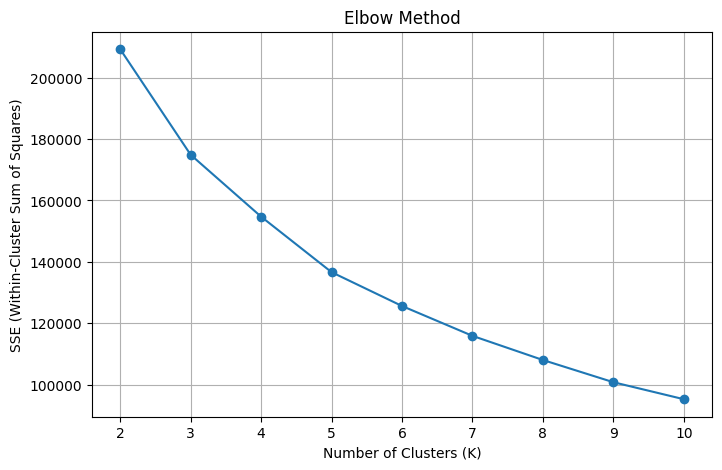

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(k_range, sse, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Within-Cluster Sum of Squares)')
plt.title('Elbow Method')

plt.xticks(k_range)
plt.grid(True)
plt.show()

In [63]:
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

In [64]:
# Save clustering model
with open('models/cluster_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("✅ Clustering model saved")

✅ Clustering model saved


In [65]:
diamond['cluster'] = cluster_labels

In [66]:
diamond.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z,volume,PricePerCarat,dimension_ratio,carat_original,carat_category,price_inr,cluster
0,0.207014,4.0,1.0,1.0,61.5,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,1.631687,0.23,Light,544.835252,1
1,0.190620,3.0,1.0,2.0,59.8,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,1.673160,0.21,Light,544.835252,1
2,0.207014,1.0,1.0,4.0,56.9,65.0,5.793014,4.05,4.07,2.31,38.076885,27.983657,1.757576,0.23,Light,545.122581,1
3,0.254642,3.0,5.0,3.0,62.4,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,1.602662,0.29,Light,547.109683,1
4,0.270027,1.0,6.0,1.0,63.3,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,1.580000,0.31,Light,547.390160,1


In [67]:
# Calculate cluster statistics
cluster_summary = diamond.groupby('cluster').agg({
    'price': 'mean',
    'carat': 'mean',
    'cut': lambda x: x.mode()[0],
    'color': lambda x: x.mode()[0],
    'clarity': lambda x: x.mode()[0],
    'cluster': 'count'
}).rename(columns={'cluster': 'count'})

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
            price     carat  cut  color  clarity  count
cluster                                                
0        9.106226  0.926299  3.0    4.0      1.0  10380
1        6.858054  0.332523  4.0    1.0      3.0  24202
2        8.242199  0.634953  4.0    2.0      2.0  19355


In [68]:
clustering_data=diamond

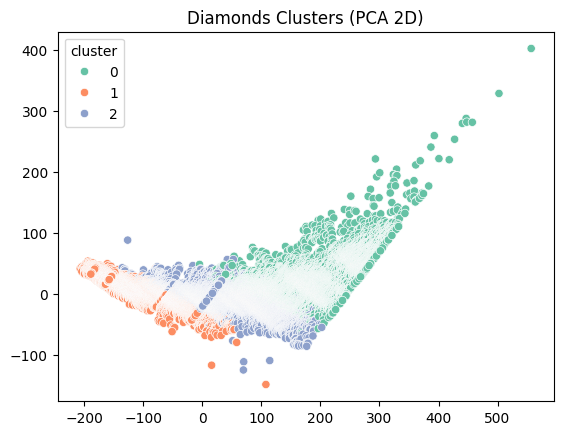

In [69]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(clustering_data.drop(['cluster', 'carat_category'], axis=1))

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=clustering_data['cluster'], palette='Set2')
plt.title('Diamonds Clusters (PCA 2D)')
plt.show()

In [70]:
# Convert transformed values back to original scale
cluster_summary['carat_original'] = np.expm1(cluster_summary['carat'])
cluster_summary['price_original'] = np.expm1(cluster_summary['price'])

# Rank clusters based on average price
cluster_order = cluster_summary['price_original'].sort_values().index

# Assign names according to price ranking
cluster_names = {
    cluster_order[0]: 'Affordable Small Diamonds',
    cluster_order[1]: 'Mid-range Balanced Diamonds',
    cluster_order[2]: 'Premium Heavy Diamonds'
}

cluster_summary['Cluster_Name'] = cluster_summary.index.map(cluster_names)

print(cluster_summary[['count', 'carat_original',
                       'price_original', 'Cluster_Name']])

         count  carat_original  price_original                 Cluster_Name
cluster                                                                    
0        10380        1.525148     9010.218863       Premium Heavy Diamonds
1        24202        0.394482      950.514094    Affordable Small Diamonds
2        19355        0.886934     3796.880931  Mid-range Balanced Diamonds


In [71]:
#SAVE CLUSTER NAMES
CLUSTER_NAMES = dict(zip(cluster_summary.index, cluster_summary['Cluster_Name']))
with open('models/cluster_names.pkl', 'wb') as f:
    pickle.dump(CLUSTER_NAMES, f)
print("Cluster names saved")
print(CLUSTER_NAMES)

Cluster names saved
{0: 'Premium Heavy Diamonds', 1: 'Affordable Small Diamonds', 2: 'Mid-range Balanced Diamonds'}
